# Atividade 05 — Avaliação de Regressão: Treino/Teste e CV(5)

**Script R equivalente:** [`../scriptsR/05-regressao-linear-treino-teste.R`](../scriptsR/05-regressao-linear-treino-teste.R)

**Explicação detalhada (consolidado):** [consolidado/05-regressao-linear-treino-teste.md](https://github.com/Megalonnix/proj_ivan_gustavo_jorge_IPDM/blob/main/consolidado/05-regressao-linear-treino-teste.md)

**Propósito deste notebook:** permitir a execução desta atividade no Google Colab (runtime R), exibindo todas as saídas e gráficos inline. Diferente do script `.R`, este notebook **não grava arquivos** — não salva `.png` nem relatórios `.md`.

**Alvo:** `mortalidade_60_69` (mortes por mil hab.).

**Como rodar no Colab:** `Runtime` → `Change runtime type` → selecionar **R** → `Run all`.


In [1]:
# =============================================================
# SETUP — Atividade 05
# =============================================================
# No Google Colab: Runtime > Change runtime type > R
# Esta atividade nao requer pacotes externos.

options(repr.plot.width = 8, repr.plot.height = 7)

cat("[INFO] Setup concluido.\n")

[INFO] Setup concluido.


In [2]:
# =============================================================
# DADOS — Atividade 05
# =============================================================
arquivo_local <- file.path("..", "bancoDeDados", "df_ipdm_baixada_por_municipio.csv")
url_github    <- "https://raw.githubusercontent.com/Megalonnix/proj_ivan_gustavo_jorge_IPDM/main/estrutura/bancoDeDados/df_ipdm_baixada_por_municipio.csv"
origem_dados <- if (file.exists(arquivo_local)) arquivo_local else url_github
if (file.exists(arquivo_local)) cat("[INFO] Carregando banco LOCAL.\n") else cat("[INFO] Carregando do GitHub.\n")

dados_brutos <- read.csv(origem_dados, sep = ";", dec = ",", fileEncoding = "latin1",
                         check.names = FALSE, stringsAsFactors = FALSE)

dados <- data.frame(
  escolaridade      = as.numeric(dados_brutos[[6]]),
  mortalidade_60_69 = as.numeric(dados_brutos[[8]]),
  distorcao_em      = as.numeric(dados_brutos[[9]])
)

rmse_fun <- function(y, yh) sqrt(mean((y - yh)^2))
mae_fun  <- function(y, yh) mean(abs(y - yh))
r2_fun   <- function(y, yh) 1 - sum((y - yh)^2) / sum((y - mean(y))^2)

cat("[INFO] Dados carregados:", nrow(dados), "linhas.\n")

[INFO] Carregando banco LOCAL.
[INFO] Dados carregados: 54 linhas.


In [3]:
# =============================================================
# ANALISE — Atividade 05
# =============================================================
set.seed(1); n <- nrow(dados)
idx <- sample(seq_len(n), floor(0.7 * n))
treino <- dados[idx, ]; teste <- dados[-idx, ]

m_s <- lm(mortalidade_60_69 ~ escolaridade,                 data = treino)
m_m <- lm(mortalidade_60_69 ~ escolaridade + distorcao_em,  data = treino)

cat("\n================ MODELOS (TREINO) ================\n")
cat("--- A: simples ---\n"); print(round(coef(summary(m_s)), 4))
cat("--- B: multiplo ---\n"); print(round(coef(summary(m_m)), 4))

ps <- predict(m_s, newdata = teste)
pm <- predict(m_m, newdata = teste)
pb <- rep(mean(treino$mortalidade_60_69), nrow(teste))

cat("\n================ TESTE (n =", nrow(teste), ") ================\n")
print(data.frame(
  Candidato = c("Baseline","A: simples","B: multiplo"),
  RMSE = round(c(rmse_fun(teste$mortalidade_60_69, pb),
                 rmse_fun(teste$mortalidade_60_69, ps),
                 rmse_fun(teste$mortalidade_60_69, pm)), 4),
  MAE  = round(c(mae_fun(teste$mortalidade_60_69, pb),
                 mae_fun(teste$mortalidade_60_69, ps),
                 mae_fun(teste$mortalidade_60_69, pm)), 4),
  R2   = c(NA, round(r2_fun(teste$mortalidade_60_69, ps), 4),
           round(r2_fun(teste$mortalidade_60_69, pm), 4))
))

# CV(5)
k <- 5; set.seed(1); dobra <- sample(rep(1:k, length = n))
e_s <- numeric(k); e_m <- numeric(k); e_b <- numeric(k)
for (j in 1:k) {
  tr <- dados[dobra != j, ]; te <- dados[dobra == j, ]
  m1 <- lm(mortalidade_60_69 ~ escolaridade, data = tr)
  m2 <- lm(mortalidade_60_69 ~ escolaridade + distorcao_em, data = tr)
  e_s[j] <- mean((te$mortalidade_60_69 - predict(m1, newdata = te))^2)
  e_m[j] <- mean((te$mortalidade_60_69 - predict(m2, newdata = te))^2)
  e_b[j] <- mean((te$mortalidade_60_69 - mean(tr$mortalidade_60_69))^2)
}
cv_s <- sqrt(mean(e_s)); cv_m <- sqrt(mean(e_m)); cv_b <- sqrt(mean(e_b))

cat("\n================ CV(5) ================\n")
print(data.frame(Candidato = c("Baseline","A: simples","B: multiplo"),
                 RMSE_CV = round(c(cv_b, cv_s, cv_m), 4)))
cat("sd(Y) =", round(sd(dados$mortalidade_60_69), 4), "\n")
cat("Dobras A venceu:", sum(e_s < e_m), "| B venceu:", sum(e_m < e_s), "\n")

# Volatilidade: 200 splits avulsos
set.seed(1)
av_s <- replicate(200, {
  i <- sample(n, floor(0.7*n)); ma <- lm(mortalidade_60_69 ~ escolaridade, data = dados[i,])
  mean((dados$mortalidade_60_69[-i] - predict(ma, newdata = dados[-i,]))^2)
})
av_m <- replicate(200, {
  i <- sample(n, floor(0.7*n)); ma <- lm(mortalidade_60_69 ~ escolaridade + distorcao_em, data = dados[i,])
  mean((dados$mortalidade_60_69[-i] - predict(ma, newdata = dados[-i,]))^2)
})

cat("\nVencedor (CV): ", if (cv_s < cv_m) "A: simples" else "B: multiplo", "\n")


================ MODELOS (TREINO) ================
--- A: simples ---
             Estimate Std. Error t value Pr(>|t|)
(Intercept)   24.0136     5.0905  4.7174   0.0000
escolaridade  -8.8190    10.3339 -0.8534   0.3992
--- B: multiplo ---
             Estimate Std. Error t value Pr(>|t|)
(Intercept)   20.4344     8.0746  2.5307   0.0162
escolaridade  -5.6044    11.8388 -0.4734   0.6390
distorcao_em   0.1191     0.2072  0.5747   0.5692

================ TESTE (n = 17 ) ================
    Candidato   RMSE    MAE      R2
1    Baseline 3.6782 2.9734      NA
2  A: simples 3.8314 3.1914 -0.1187
3 B: multiplo 3.7887 3.0999 -0.0939

================ CV(5) ================
    Candidato RMSE_CV
1    Baseline  3.8425
2  A: simples  3.8945
3 B: multiplo  4.0319
sd(Y) = 3.8504 
Dobras A venceu: 1 | B venceu: 4 

Vencedor (CV):  A: simples 


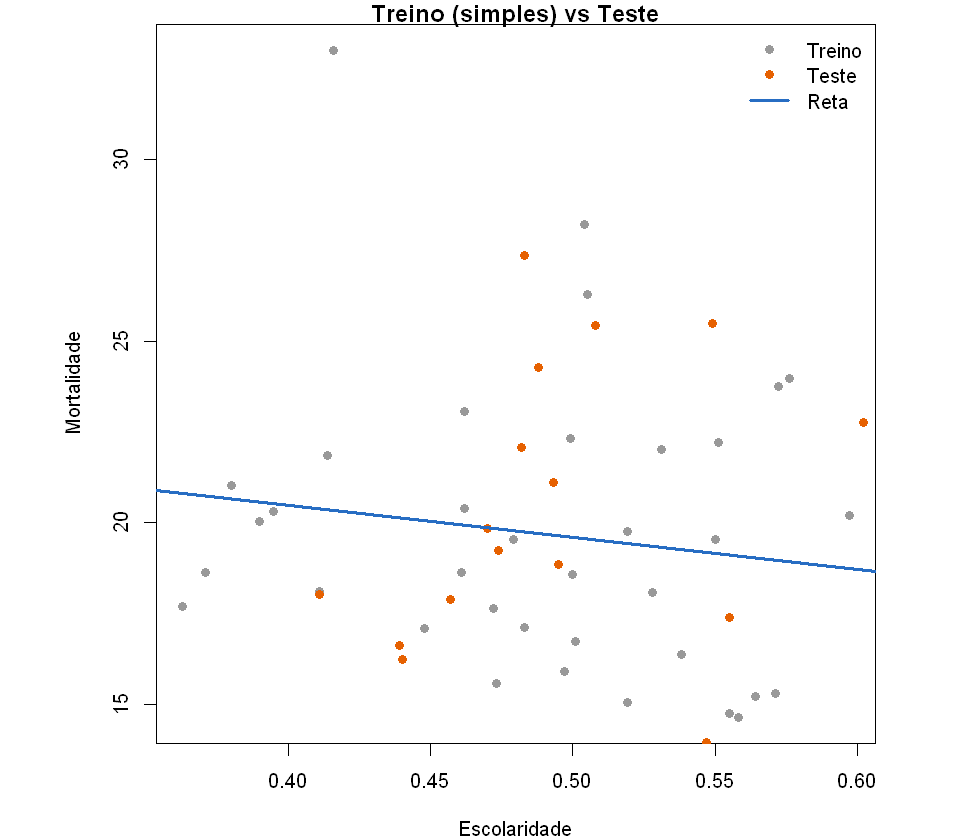

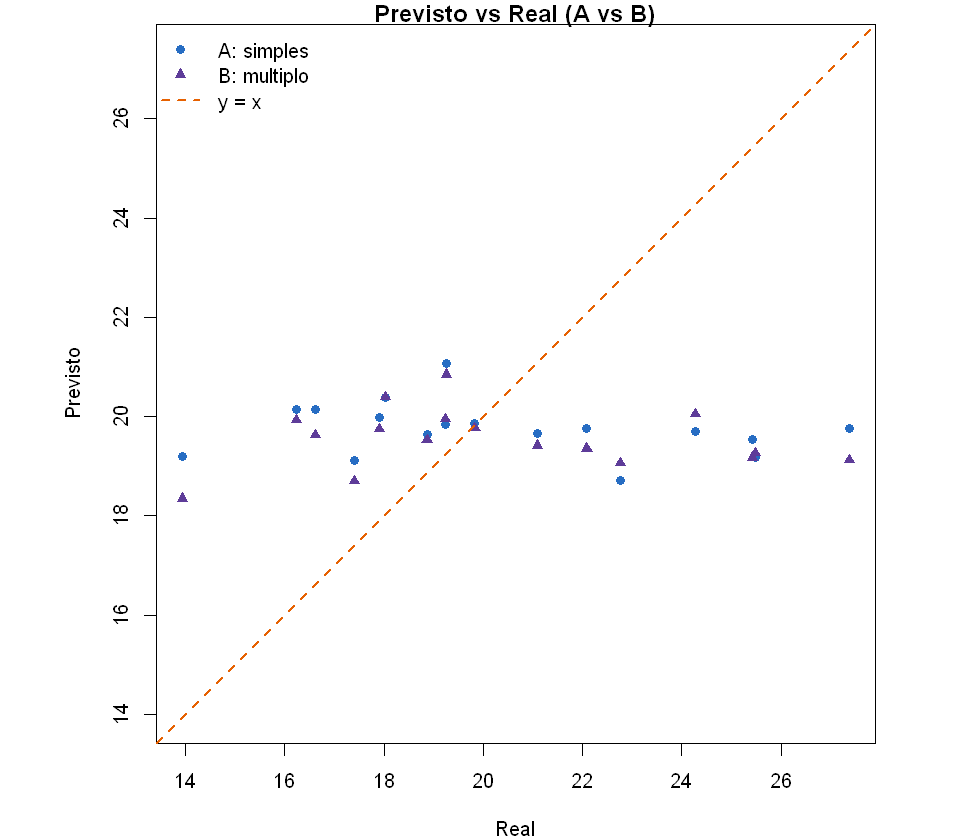

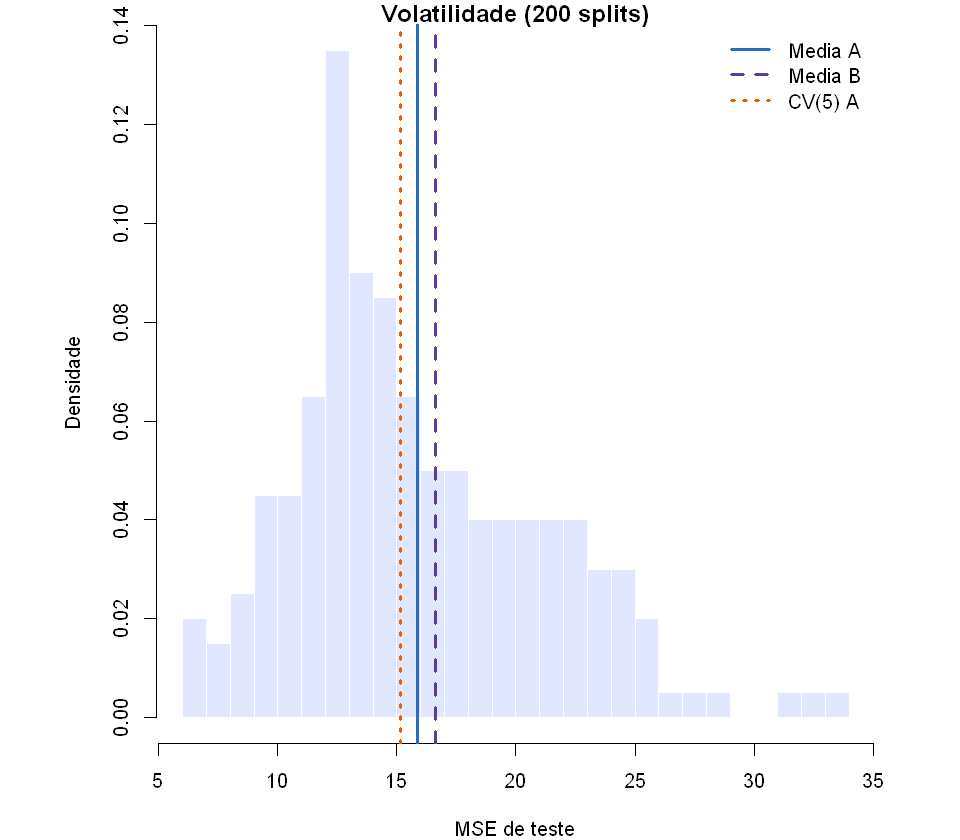

In [4]:
# =============================================================
# GRAFICOS — Atividade 05
# =============================================================
cazul <- "#276DC3"; claranja <- "#E66101"; croxo <- "#5E3C99"; cfill <- "#E0E7FF"

# Grafico 1 — treino + teste
par(mar = c(4,4,1,1), pty = "s")
plot(treino$escolaridade, treino$mortalidade_60_69, col = "gray60", pch = 16,
     xlab = "Escolaridade", ylab = "Mortalidade",
     main = "Treino (simples) vs Teste")
points(teste$escolaridade, teste$mortalidade_60_69, col = claranja, pch = 19)
abline(m_s, col = cazul, lwd = 3)
legend("topright", c("Treino","Teste","Reta"),
       col = c("gray60",claranja,cazul), pch = c(16,19,NA),
       lwd = c(NA,NA,3), lty = c(NA,NA,1), bty = "n")

# Grafico 2 — previsto vs real (A vs B)
par(mar = c(4,4,1,1), pty = "s")
rng <- range(c(teste$mortalidade_60_69, ps, pm))
plot(teste$mortalidade_60_69, ps, col = cazul, pch = 19, xlim = rng, ylim = rng,
     xlab = "Real", ylab = "Previsto", main = "Previsto vs Real (A vs B)")
points(teste$mortalidade_60_69, pm, col = croxo, pch = 17)
abline(0, 1, lty = 2, col = claranja, lwd = 2)
legend("topleft", c("A: simples","B: multiplo","y = x"),
       col = c(cazul,croxo,claranja), pch = c(19,17,NA),
       lwd = c(NA,NA,2), lty = c(NA,NA,2), bty = "n")

# Grafico 3 — volatilidade do MSE (200 splits)
par(mar = c(4,4,1,1), pty = "s")
hist(av_s, breaks = 20, prob = TRUE, col = cfill, border = "white",
     xlab = "MSE de teste", ylab = "Densidade", main = "Volatilidade (200 splits)")
abline(v = mean(av_s), col = cazul,    lwd = 3)
abline(v = mean(av_m), col = croxo,    lwd = 3, lty = 2)
abline(v = cv_s^2,     col = claranja, lwd = 3, lty = 3)
legend("topright", c("Media A","Media B","CV(5) A"),
       col = c(cazul,croxo,claranja), lwd = 3, lty = c(1,2,3), bty = "n")